## What is happening in the next code?
This code prepares a last model that learns from all the available images: train, validation, and test together. It creates an `all_data_model` output folder and loads the already evaluated final model (`resnet18_trainval_final.pt`) as the starting point, without overwriting it. From this checkpoint it reads the class mapping and builds the sorted list of class names.
It joins the three CSV files into one table (`all_df`) and runs safety checks: no repeated image paths or file hashes, the labels match the class mapping, and every image file really exists on disk. Then it saves the joined table as `all_training_manifest.csv`.
Finally, it shows a table with the number of images per class, and prints the device, the starting checkpoint, the total number of images, and the number of missing paths (it should be 0).

In [1]:
from pathlib import Path
import pandas as pd
import torch

PROJECT_ROOT = Path(
    r"D:\Maktab_Sharif_Projects\traffic-vehicle-classification"
)
MANIFEST_DIR = PROJECT_ROOT / "data" / "manifests"

ALL_DATA_DIR = PROJECT_ROOT / "outputs" / "all_data_model"
ALL_DATA_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cpu")

# Start from the evaluated model without overwriting it.
START_CHECKPOINT = (
    PROJECT_ROOT / "outputs" / "final_model"
    / "resnet18_trainval_final.pt"
)

starting = torch.load(
    START_CHECKPOINT,
    map_location="cpu",
    weights_only=True
)

class_to_idx = starting["class_to_idx"]
classes = sorted(class_to_idx, key=class_to_idx.get)

all_df = pd.concat(
    [
        pd.read_csv(MANIFEST_DIR / "train.csv"),
        pd.read_csv(MANIFEST_DIR / "validation.csv"),
        pd.read_csv(MANIFEST_DIR / "test.csv"),
    ],
    ignore_index=True
)

assert all_df["path"].is_unique
assert all_df["sha256"].is_unique
assert set(all_df["label"]) == set(class_to_idx)

missing_paths = [
    path for path in all_df["path"]
    if not Path(path).is_file()
]
assert not missing_paths, f"Missing images: {len(missing_paths)}"

all_df.to_csv(
    ALL_DATA_DIR / "all_training_manifest.csv",
    index=False
)

display(
    all_df["label"]
    .value_counts()
    .reindex(classes)
    .rename("training_images")
    .to_frame()
)

print("Device:", DEVICE)
print("Starting checkpoint:", START_CHECKPOINT.name)
print("Total training images:", len(all_df))
print("Missing image paths:", len(missing_paths))
print("All-data manifest saved.")

,training_images
label,
ambulance,408
autobus,520
kamyun,437
kamyunet,614
minibus,434
savari,352
taxi,348
vanet,399


Device: cpu
Starting checkpoint: resnet18_trainval_final.pt
Total training images: 3512
Missing image paths: 0
All-data manifest saved.


## What is happening in the next code?
This code writes down the recipe for the all-data training run and saves it as `all_data_training_recipe.json`. It starts from a copy of the settings stored in the previous final checkpoint, so the image settings (size, padding color, normalization, flip, color changes) stay the same, and then updates the training settings.
The recipe sets ResNet18 with Dropout 0.25, BCE loss, balanced batches of 16, a fresh AdamW optimizer, and 8 fixed epochs with no scheduler. Only `layer3`, `layer4`, and `fc` learn. The three learning rates are now fixed at lower values (0.0000015, 0.000005, 0.000015) than before, which makes this run a gentler update of the already trained model.
It also stores the number of images (train + validation + test), a note that no held-out evaluation is possible (`local_held_out_evaluation: False`), and a SHA-256 fingerprint of the all-data manifest, so you can later prove which data was used.
Finally, it prints the main settings and the save location.

In [2]:
import copy
import hashlib
import json

ALL_DATA_RECIPE = copy.deepcopy(starting["config"])

ALL_DATA_RECIPE.update({
    "architecture": "resnet18",
    "initialization": "train_validation_checkpoint",
    "starting_checkpoint": START_CHECKPOINT.name,
    "trainable_layers": ["layer3", "layer4", "fc"],
    "dropout": 0.25,
    "loss": "bce",
    "sampling": "balanced",
    "batch_size": 16,
    "epochs": 8,
    "optimizer": "AdamW",
    "optimizer_state": "fresh",
    "layer3_lr": 1.5e-6,
    "layer4_lr": 5e-6,
    "fc_lr": 1.5e-5,
    "weight_decay": 1e-4,
    "scheduler": "none_fixed_learning_rates",
    "batchnorm_running_stats": "fixed",
    "seed": 42,
    "training_images": len(all_df),
    "checkpoint_rule": "save_after_final_epoch",
    "stage": "all_data_refit",
    "local_held_out_evaluation": False,
})

manifest_path = ALL_DATA_DIR / "all_training_manifest.csv"

ALL_DATA_RECIPE["training_manifest_sha256"] = hashlib.sha256(
    manifest_path.read_bytes()
).hexdigest()

recipe_path = ALL_DATA_DIR / "all_data_training_recipe.json"

with recipe_path.open("w", encoding="utf-8") as file:
    json.dump(ALL_DATA_RECIPE, file, indent=2)

print("Training images:", ALL_DATA_RECIPE["training_images"])
print("Fixed epochs:", ALL_DATA_RECIPE["epochs"])
print("Dropout:", ALL_DATA_RECIPE["dropout"])
print("Sampling:", ALL_DATA_RECIPE["sampling"])
print("Loss:", ALL_DATA_RECIPE["loss"])
print("Learning rates: fixed")
print("Augmentation: preserved from the previous recipe")
print("Recipe saved:", recipe_path)

Training images: 3512
Fixed epochs: 8
Dropout: 0.25
Sampling: balanced
Loss: bce
Learning rates: fixed
Augmentation: preserved from the previous recipe
Recipe saved: D:\Maktab_Sharif_Projects\traffic-vehicle-classification\outputs\all_data_model\all_data_training_recipe.json


## What is happening in the next code?
This code builds the training data loader for the all-data run (train + validation + test images). It sets the random seed (42) from the recipe, then defines the image steps: random horizontal flip, small color changes, resize to 224x274 style padding (224x224 with gray padding, no stretching), tensor conversion, and normalization.
An `AllDataDataset` class loads one image, fixes its rotation, converts it to RGB, applies the transform, and turns the label into a number. A `BalancedBatchSampler` builds each batch with 2 images from each of the 8 classes (16 images). When a class runs out of images, it reshuffles that class and continues, so small classes are repeated more often.
The number of batches per epoch is the number of images divided by 16, rounded up, so one epoch makes about as many image draws as there are images. The loader uses this sampler and a seeded generator, so the run can be repeated.
Finally, it prints the number of unique images, the batches per epoch, the image draws per epoch, the images per class in each batch, and the augmentation settings. No training starts yet.

In [3]:
import math
import random
import numpy as np

from PIL import Image, ImageOps
from torch.utils.data import Dataset, DataLoader, Sampler
from torchvision import transforms

SEED = ALL_DATA_RECIPE["seed"]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


class ResizeWithPadding:
    def __init__(self, size=224, color=(124, 116, 104)):
        self.size = size
        self.color = tuple(color)

    def __call__(self, image):
        resized = ImageOps.contain(
            image,
            (self.size, self.size),
            method=Image.Resampling.BILINEAR,
        )

        canvas = Image.new(
            "RGB", (self.size, self.size), self.color
        )

        position = (
            (self.size - resized.width) // 2,
            (self.size - resized.height) // 2,
        )
        canvas.paste(resized, position)
        return canvas


all_train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
    ),
    ResizeWithPadding(
        size=ALL_DATA_RECIPE["image_size"],
        color=(124, 116, 104),
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=ALL_DATA_RECIPE["mean"],
        std=ALL_DATA_RECIPE["std"],
    ),
])


class AllDataDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        with Image.open(row["path"]) as image:
            image = ImageOps.exif_transpose(image).convert("RGB")
            image = self.transform(image)

        label = class_to_idx[row["label"]]
        return image, label


class BalancedBatchSampler(Sampler):
    def __init__(
        self, labels, samples_per_class=2,
        batches_per_epoch=220, seed=42
    ):
        self.labels = np.asarray(labels)
        self.classes = sorted(np.unique(self.labels))
        self.indices = {
            label: np.flatnonzero(self.labels == label)
            for label in self.classes
        }

        self.samples_per_class = samples_per_class
        self.batches_per_epoch = batches_per_epoch
        self.seed = seed
        self.epoch = 0

        assert all(
            len(indices) >= samples_per_class
            for indices in self.indices.values()
        )

    def __len__(self):
        return self.batches_per_epoch

    def __iter__(self):
        rng = np.random.default_rng(self.seed + self.epoch)
        self.epoch += 1

        pools = {
            label: rng.permutation(indices)
            for label, indices in self.indices.items()
        }
        positions = {label: 0 for label in self.classes}

        for _ in range(self.batches_per_epoch):
            batch = []

            for label in self.classes:
                start = positions[label]
                end = start + self.samples_per_class

                if end > len(pools[label]):
                    pools[label] = rng.permutation(self.indices[label])
                    start = 0
                    end = self.samples_per_class

                batch.extend(pools[label][start:end].tolist())
                positions[label] = end

            rng.shuffle(batch)
            yield batch


all_dataset = AllDataDataset(all_df, all_train_transform)

all_sampler = BalancedBatchSampler(
    labels=all_df["label"].to_numpy(),
    samples_per_class=2,
    batches_per_epoch=math.ceil(
        len(all_dataset) / ALL_DATA_RECIPE["batch_size"]
    ),
    seed=SEED,
)

all_generator = torch.Generator().manual_seed(SEED)

all_loader = DataLoader(
    all_dataset,
    batch_sampler=all_sampler,
    num_workers=0,
    generator=all_generator,
)

print("Unique training images:", len(all_dataset))
print("Batches per epoch:", len(all_loader))
print("Image draws per epoch:", len(all_loader) * 16)
print("Images per class in each batch: 2")
print("Augmentation: horizontal flip + color jitter")
print("All-data training loader ready.")

Unique training images: 3512
Batches per epoch: 220
Image draws per epoch: 3520
Images per class in each batch: 2
Augmentation: horizontal flip + color jitter
All-data training loader ready.


## What is happening in the next code?
This code builds the model for the all-data run. It creates an empty ResNet18, puts a Dropout(0.25) layer before the final layer (`fc`), and loads the weights of the evaluated final model (`resnet18_trainval_final.pt`), so training continues from it.
It freezes all layers, then unfreezes only `layer3`, `layer4`, and `fc`, and moves the model to the CPU. It creates a fresh AdamW optimizer with three fixed learning rates from the recipe (0.0000015, 0.000005, 0.000015), and uses `BCEWithLogitsLoss` as the loss, which treats every class as its own yes/no question.
It defines `set_all_data_training_mode()`, a helper for the training loop: the whole model goes to eval mode, then only `layer3`, `layer4`, and `fc` go to train mode (so dropout is active), and all BatchNorm layers are put back in eval mode so their running statistics do not change.
Finally, it prints the starting checkpoint, the classifier, the number of trainable parameters, the optimizer, the loss, the number of epochs (8), and the learning rate of each layer group. No training starts yet.

In [9]:
import torch.nn as nn
from torchvision import models
import torch.nn.functional as F


all_model = models.resnet18(weights=None)

all_model.fc = nn.Sequential(
    nn.Dropout(p=ALL_DATA_RECIPE["dropout"]),
    nn.Linear(all_model.fc.in_features, len(classes)),
)

all_model.load_state_dict(starting["model_state_dict"])

for parameter in all_model.parameters():
    parameter.requires_grad = False

for layer_name in ALL_DATA_RECIPE["trainable_layers"]:
    for parameter in getattr(all_model, layer_name).parameters():
        parameter.requires_grad = True

all_model = all_model.to(DEVICE)

all_optimizer = torch.optim.AdamW(
    [
        {
            "params": all_model.layer3.parameters(),
            "lr": ALL_DATA_RECIPE["layer3_lr"],
        },
        {
            "params": all_model.layer4.parameters(),
            "lr": ALL_DATA_RECIPE["layer4_lr"],
        },
        {
            "params": all_model.fc.parameters(),
            "lr": ALL_DATA_RECIPE["fc_lr"],
        },
    ],
    weight_decay=ALL_DATA_RECIPE["weight_decay"],
)

all_criterion = nn.BCEWithLogitsLoss()


def set_all_data_training_mode():
    all_model.eval()

    for layer_name in ALL_DATA_RECIPE["trainable_layers"]:
        getattr(all_model, layer_name).train()

    for module in all_model.modules():
        if isinstance(module, nn.modules.batchnorm._BatchNorm):
            module.eval()


trainable_parameters = sum(
    parameter.numel()
    for parameter in all_model.parameters()
    if parameter.requires_grad
)

print("Starting weights:", START_CHECKPOINT.name)
print("Classifier:", all_model.fc)
print("Trainable parameters:", trainable_parameters)
print("Optimizer: fresh AdamW")
print("Loss: BCEWithLogitsLoss")
print("Fixed epochs:", ALL_DATA_RECIPE["epochs"])

for name, group in zip(
    ["Layer 3", "Layer 4", "FC"],
    all_optimizer.param_groups,
):
    print(f"{name} learning rate: {group['lr']}")

Starting weights: resnet18_trainval_final.pt
Classifier: Sequential(
  (0): Dropout(p=0.25, inplace=False)
  (1): Linear(in_features=512, out_features=8, bias=True)
)
Trainable parameters: 10497544
Optimizer: fresh AdamW
Loss: BCEWithLogitsLoss
Fixed epochs: 8
Layer 3 learning rate: 1.5e-06
Layer 4 learning rate: 5e-06
FC learning rate: 1.5e-05


## What is happening in the next code?
This code defines `train_all_data_model`, the training loop for the all-data model, which learns from the train, validation, and test images for the 8 epochs fixed in `ALL_DATA_RECIPE`. It stops with an error if the final checkpoint, the recovery checkpoint, or the history file already exists, so old results are not overwritten.
Before training, it resets the random seeds, the sampler position, and the loader generator, so the run can be repeated. Each epoch it calls `set_all_data_training_mode()` (only `layer3`, `layer4`, and `fc` train, dropout is active, BatchNorm stays in eval mode). It turns the labels into one-hot vectors, calculates the BCE loss, and stops with an error if the loss becomes NaN or infinite. There is no validation step, because every image is now part of the training data.
After every epoch it saves the history to a CSV file and overwrites a recovery checkpoint. The checkpoint contains the model, the optimizer, the settings, and the sorted list of all training file hashes, so you can later prove which images were used. Files are first written to a temporary file and then renamed, so an interruption cannot leave a broken checkpoint.
After the last epoch, it saves the final checkpoint (no "best epoch" is chosen) and returns the history table.

In [10]:
import time

ALL_CHECKPOINT_PATH = ALL_DATA_DIR / "resnet18_all_data_final.pt"
ALL_RECOVERY_PATH = ALL_DATA_DIR / "resnet18_all_data_recovery.pt"
ALL_HISTORY_PATH = ALL_DATA_DIR / "all_data_training_history.csv"


def train_all_data_model():
    for path in [
        ALL_CHECKPOINT_PATH,
        ALL_RECOVERY_PATH,
        ALL_HISTORY_PATH,
    ]:
        if path.exists():
            raise FileExistsError(
                f"Existing output: {path}\n"
                "Keep it or move it before starting a new run."
            )

    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    all_sampler.epoch = 0
    all_generator.manual_seed(SEED)

    history = []
    training_hashes = sorted(all_df["sha256"].astype(str).tolist())

    for epoch in range(1, ALL_DATA_RECIPE["epochs"] + 1):
        started = time.perf_counter()
        set_all_data_training_mode()

        total_loss = 0.0
        total_correct = 0
        total_count = 0

        for images, labels in all_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            all_optimizer.zero_grad(set_to_none=True)

            logits = all_model(images)
            targets = F.one_hot(
                labels, num_classes=len(classes)
            ).to(dtype=logits.dtype)

            loss = all_criterion(logits, targets)

            if not torch.isfinite(loss):
                raise RuntimeError(
                    f"Non-finite training loss at epoch {epoch}"
                )

            loss.backward()
            all_optimizer.step()

            batch_count = labels.size(0)
            total_loss += loss.item() * batch_count
            total_correct += (
                logits.argmax(dim=1) == labels
            ).sum().item()
            total_count += batch_count

        row = {
            "epoch": epoch,
            "train_loss": total_loss / total_count,
            "train_accuracy": total_correct / total_count,
            "image_draws": total_count,
            "layer3_lr": all_optimizer.param_groups[0]["lr"],
            "layer4_lr": all_optimizer.param_groups[1]["lr"],
            "fc_lr": all_optimizer.param_groups[2]["lr"],
            "seconds": time.perf_counter() - started,
        }
        history.append(row)

        checkpoint = {
            "epoch": epoch,
            "stage": "all_data_refit",
            "model_state_dict": all_model.state_dict(),
            "optimizer_state_dict": all_optimizer.state_dict(),
            "class_to_idx": dict(class_to_idx),
            "config": copy.deepcopy(ALL_DATA_RECIPE),
            "training_sha256": training_hashes,
            "training_metrics": dict(row),
        }

        temporary_path = ALL_RECOVERY_PATH.with_suffix(".tmp")
        torch.save(checkpoint, temporary_path)
        temporary_path.replace(ALL_RECOVERY_PATH)

        pd.DataFrame(history).to_csv(
            ALL_HISTORY_PATH, index=False
        )

        print(
            f"Epoch {epoch:02d}/{ALL_DATA_RECIPE['epochs']} | "
            f"Train loss: {row['train_loss']:.6f} | "
            f"Train accuracy: {row['train_accuracy']:.2%} | "
            f"{row['seconds']:.1f}s",
            flush=True,
        )

    all_model.eval()

    temporary_path = ALL_CHECKPOINT_PATH.with_suffix(".tmp")
    torch.save(checkpoint, temporary_path)
    temporary_path.replace(ALL_CHECKPOINT_PATH)

    print("\nAll-data training completed.")
    print("Final checkpoint:", ALL_CHECKPOINT_PATH)
    print("History saved:", ALL_HISTORY_PATH)

    return pd.DataFrame(history)


print("All-data training loop ready.")

All-data training loop ready.


In [11]:
all_history = train_all_data_model()

Epoch 01/8 | Train loss: 0.010317 | Train accuracy: 99.49% | 506.8s
Epoch 02/8 | Train loss: 0.006480 | Train accuracy: 99.72% | 471.1s
Epoch 03/8 | Train loss: 0.006203 | Train accuracy: 99.66% | 481.0s
Epoch 04/8 | Train loss: 0.004769 | Train accuracy: 99.86% | 480.2s
Epoch 05/8 | Train loss: 0.006146 | Train accuracy: 99.77% | 483.2s
Epoch 06/8 | Train loss: 0.003470 | Train accuracy: 99.83% | 483.1s
Epoch 07/8 | Train loss: 0.002303 | Train accuracy: 99.89% | 502.5s
Epoch 08/8 | Train loss: 0.002422 | Train accuracy: 99.94% | 519.5s

All-data training completed.
Final checkpoint: D:\Maktab_Sharif_Projects\traffic-vehicle-classification\outputs\all_data_model\resnet18_all_data_final.pt
History saved: D:\Maktab_Sharif_Projects\traffic-vehicle-classification\outputs\all_data_model\all_data_training_history.csv


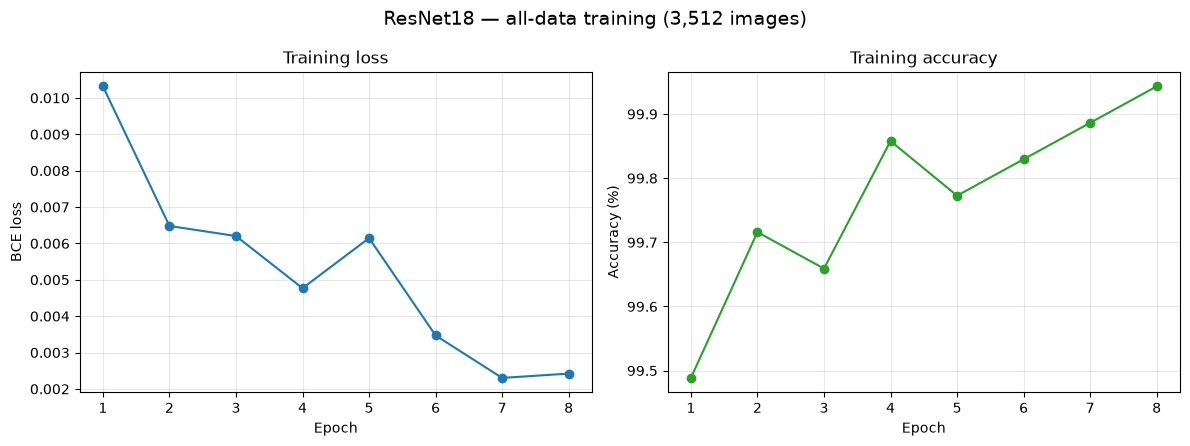

Figure saved: D:\Maktab_Sharif_Projects\traffic-vehicle-classification\outputs\figures\resnet18_all_data_training.png
Total training time: 65.5 minutes


In [12]:
import matplotlib.pyplot as plt

all_history = pd.read_csv(
    ALL_DATA_DIR / "all_data_training_history.csv"
)

FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

figure_path = FIGURE_DIR / "resnet18_all_data_training.png"

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(
    all_history["epoch"],
    all_history["train_loss"],
    marker="o",
    color="tab:blue",
)
axes[0].set_title("Training loss")
axes[0].set_ylabel("BCE loss")

axes[1].plot(
    all_history["epoch"],
    all_history["train_accuracy"] * 100,
    marker="o",
    color="tab:green",
)
axes[1].set_title("Training accuracy")
axes[1].set_ylabel("Accuracy (%)")

for ax in axes:
    ax.set_xlabel("Epoch")
    ax.set_xticks(all_history["epoch"])
    ax.grid(alpha=0.3)

fig.suptitle(
    "ResNet18 — all-data training (3,512 images)",
    fontsize=14,
)
fig.tight_layout()
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved:", figure_path)
print(
    "Total training time:",
    f"{all_history['seconds'].sum() / 60:.1f} minutes",
)